In [2]:
#importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset = pd.read_csv('drive/MyDrive/Labs/CSE422/Dataset/8.csv')
#csv read directly from github loaded onto volunteer dataframe. It can be read from google drive or locally as well

display(dataset)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [4]:
dataset.isnull().sum() #number of null values in the dataframe

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


# Introduction

The CSV ("8.csv") contains the UCI Heart Disease dataset, combining patient records from Cleveland, Hungary, Switzerland, and VA Long Beach sources. It focuses on predicting heart disease presence (target "num": 0=no disease, 1-4=severity levels) using clinical measurements.

# Dataset Description

There are 16 features in the given dataset, and 920 data points. Features are of the following types:

| Type               | Examples                                                                                                                                                             |
| ------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Numeric            | id, age, trestbps (resting BP), chol (cholesterol), thalch (max heart rate), oldpeak (ST depression), ca (vessels), num (target)​                                  |
| Categorical (text) | sex (Male/Female), dataset (Cleveland/etc.), cp (chest pain type), restecg (ECG results), exang (exercise angina), slope (ST segment), thal (thallium stress) |
| Boolean            | fbs (>120mg/dl blood sugar)​                                                                                                                                   |

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


# Data Analysis

### Feature Type

In [6]:
#Selecting Numerical Features
numerical_data = dataset.select_dtypes(include='number')
numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:')
print(numerical_features, "\n")


# Selecting Categorical Features
categorical_data=dataset.select_dtypes(include='object')
categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:')
print(categorical_features)

# fbs is defined as 'object' in the given dataset, and not detected as 'bool'

There are 8 numerical features:
['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num'] 

There are 8 categorical features:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


### Data Stats

In [7]:
display(numerical_data.var())
display(categorical_data.describe().T)

,0
id,70610.000000
age,88.824691
trestbps,363.515007
chol,12272.387943
thalch,672.171813
oldpeak,1.190775
ca,0.875447
num,1.305748


,count,unique,top,freq
sex,920,2,Male,726
dataset,920,4,Cleveland,304
cp,920,4,asymptomatic,496
fbs,830,2,False,692
restecg,918,3,normal,551
exang,865,2,False,528
slope,611,3,flat,345
thal,434,3,normal,196


### Skewness

In [8]:
numerical_data.skew()

,0
id,0.000000
age,-0.195994
trestbps,0.213334
chol,-0.613836
thalch,-0.211119
oldpeak,1.041427
ca,1.165978
num,0.968880


### Outlier Detection

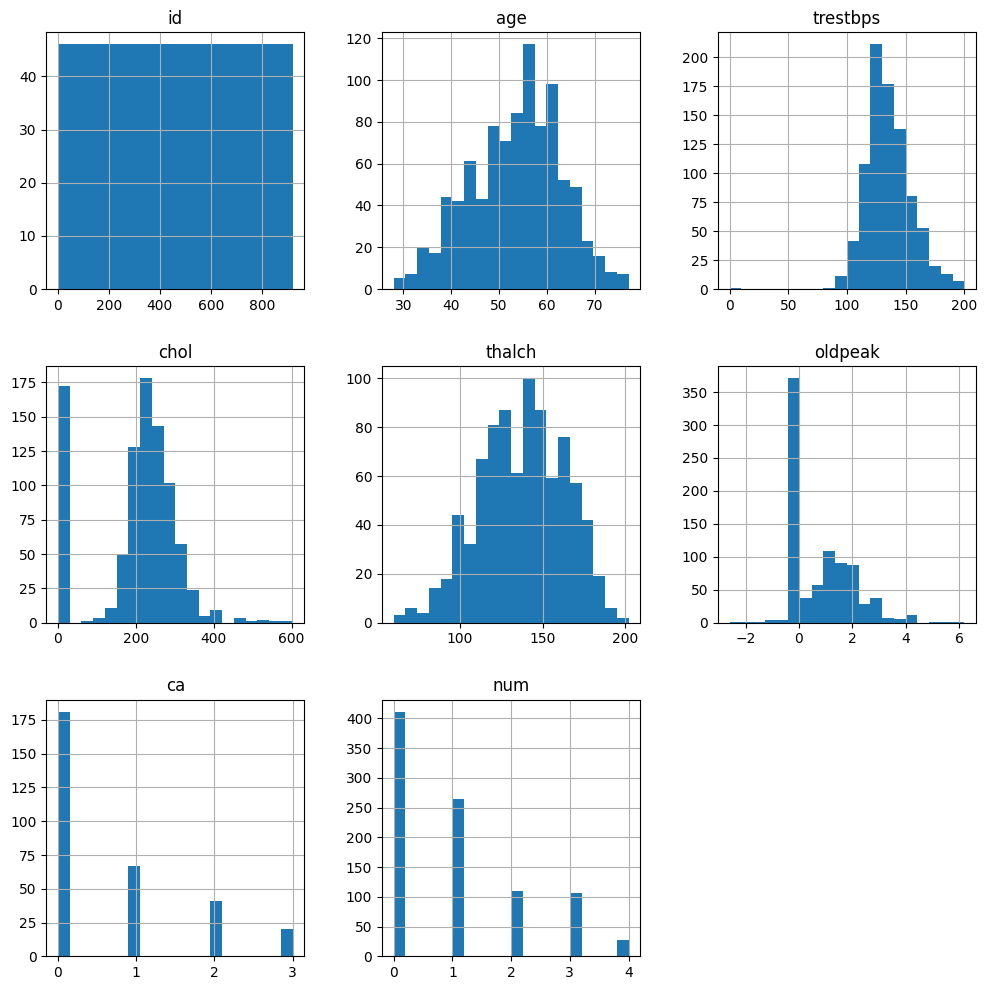

In [9]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

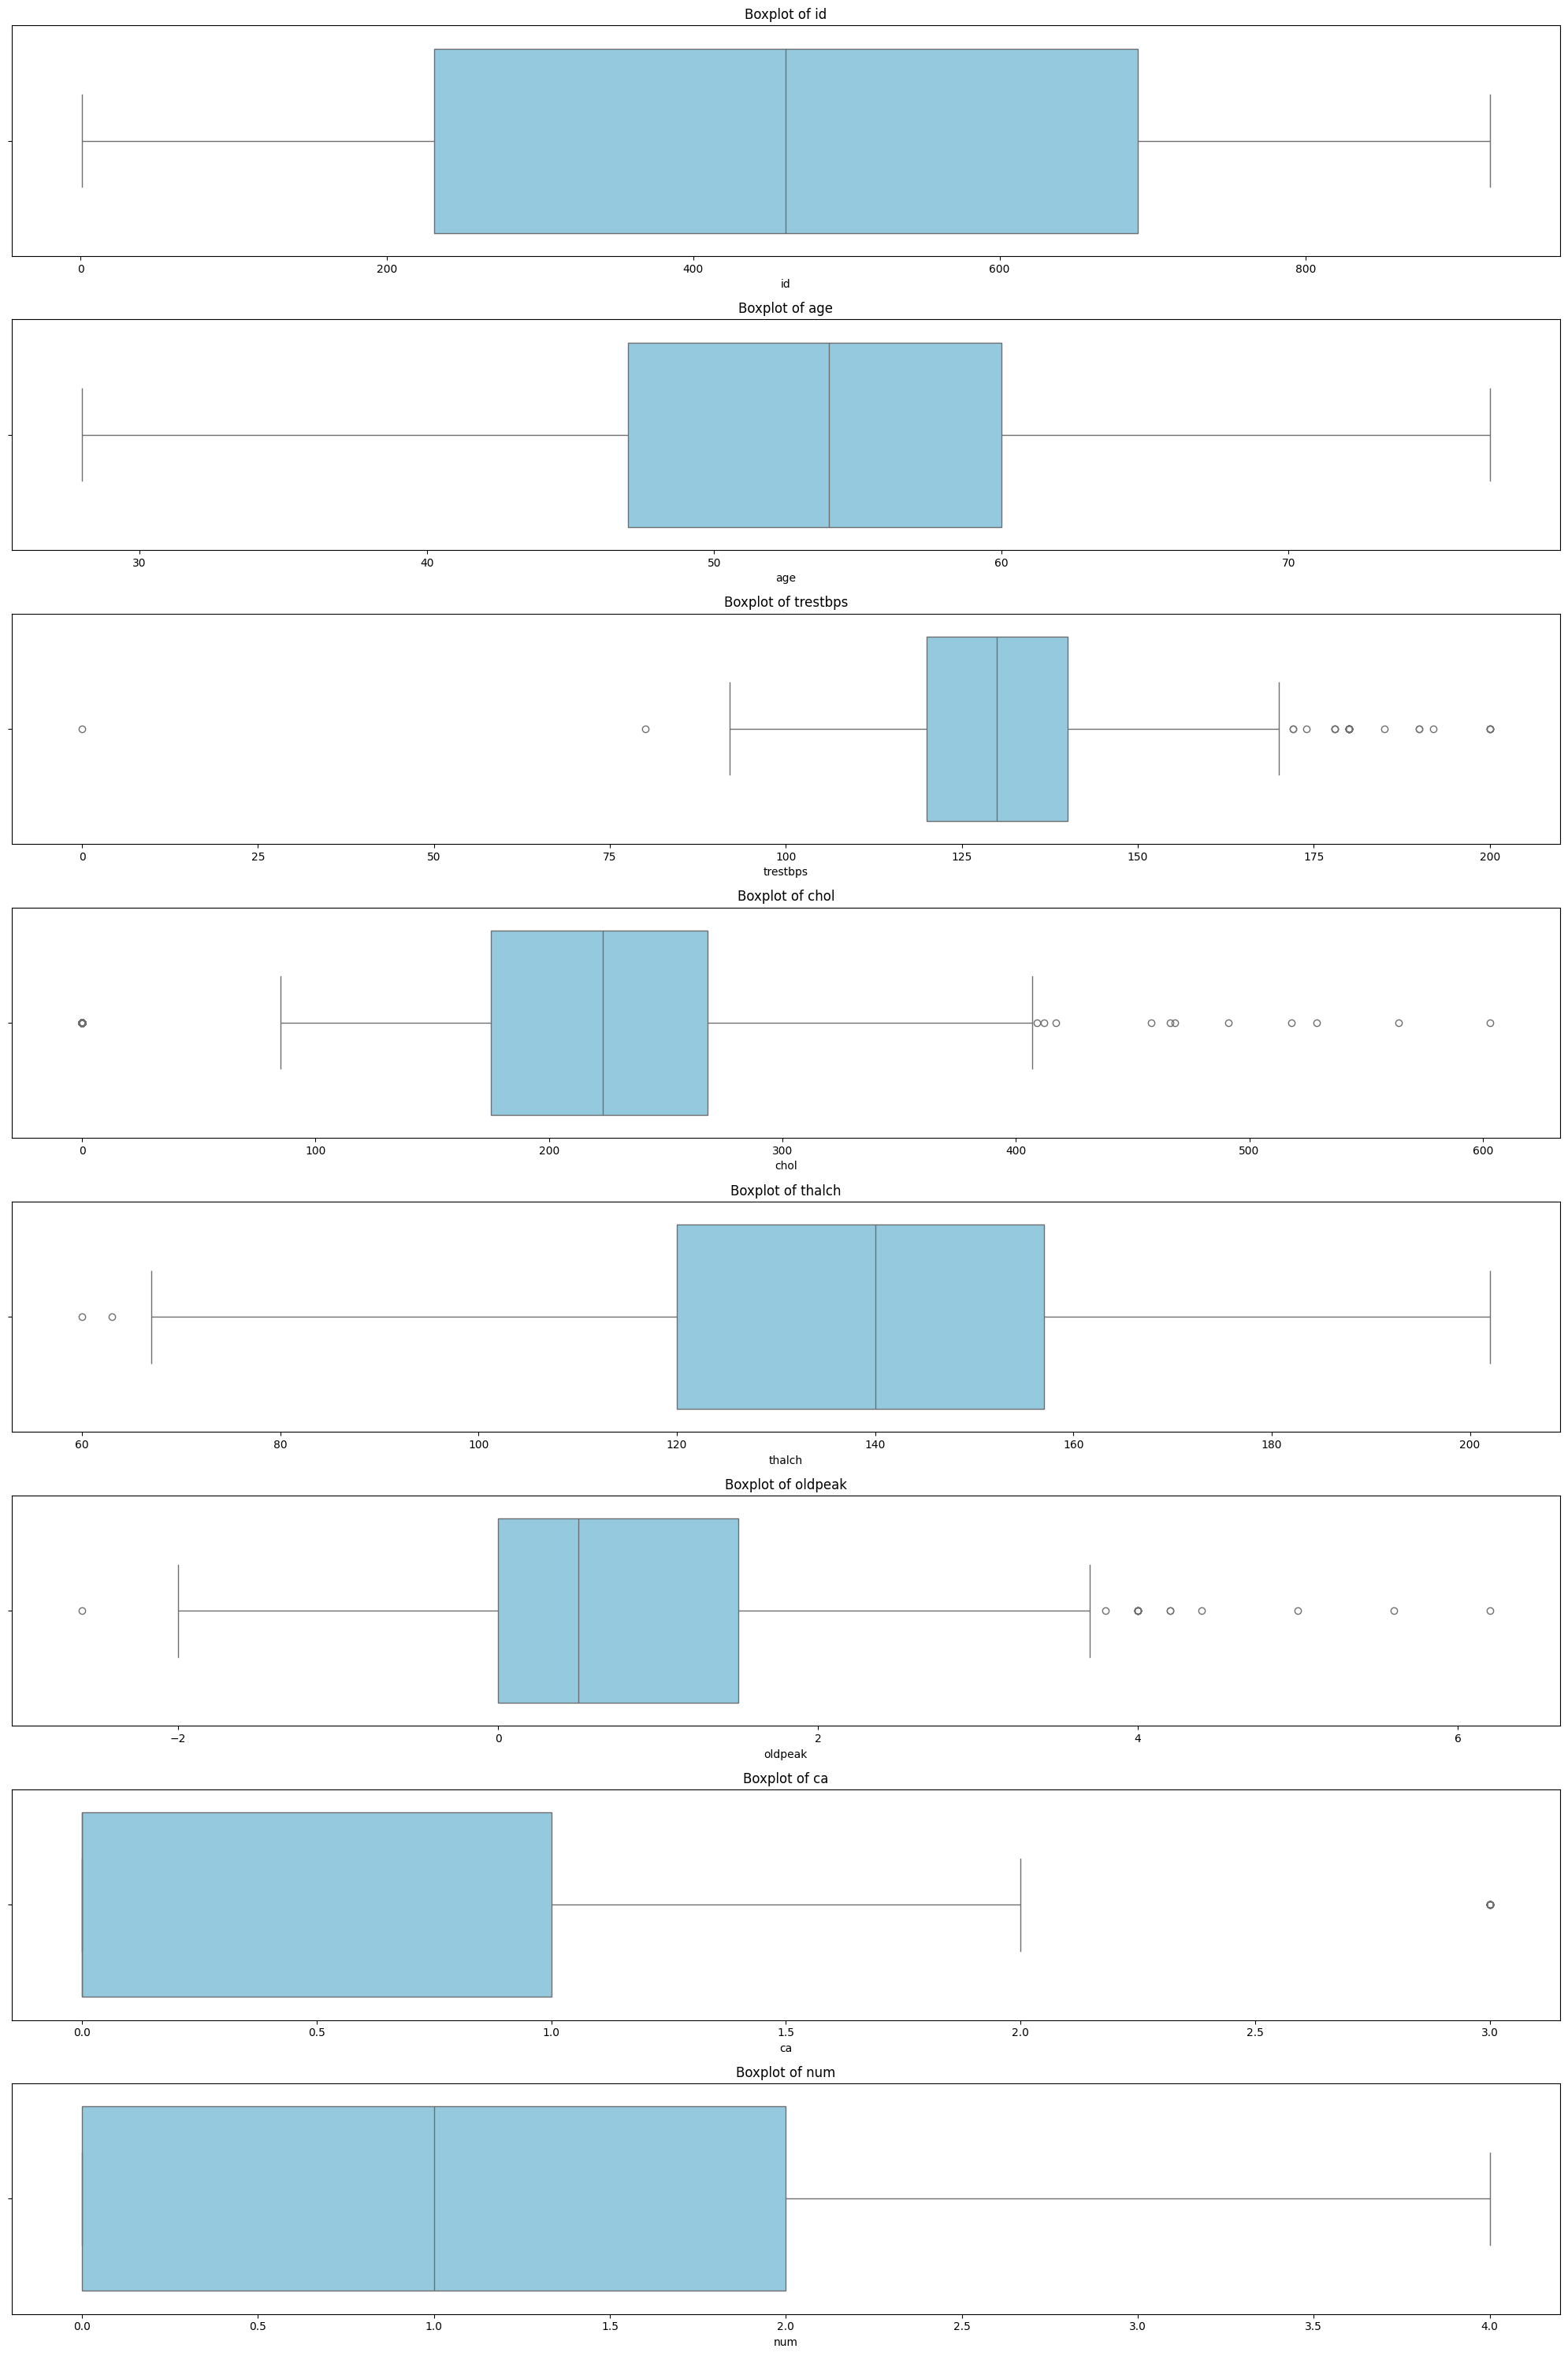

In [10]:
# Select only numerical columns for boxplot analysis
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

# Set up the figure
plt.figure(figsize=(20, 30))

# Plot boxplots for each numerical feature including the target variable 'OUTCOME'
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

### Correlation Matrix

,id,age,trestbps,chol,thalch,oldpeak,ca,num
id,1.000000,0.239301,0.052924,-0.376936,-0.466427,0.049930,0.061433,0.273552
age,0.239301,1.000000,0.244253,-0.086234,-0.365778,0.258243,0.370416,0.339596
trestbps,0.052924,0.244253,1.000000,0.092853,-0.104899,0.161908,0.093705,0.122291
chol,-0.376936,-0.086234,0.092853,1.000000,0.236121,0.047734,0.051606,-0.231547
thalch,-0.466427,-0.365778,-0.104899,0.236121,1.000000,-0.151174,-0.264094,-0.366265
oldpeak,0.049930,0.258243,0.161908,0.047734,-0.151174,1.000000,0.281817,0.443084
ca,0.061433,0.370416,0.093705,0.051606,-0.264094,0.281817,1.000000,0.516216
num,0.273552,0.339596,0.122291,-0.231547,-0.366265,0.443084,0.516216,1.000000


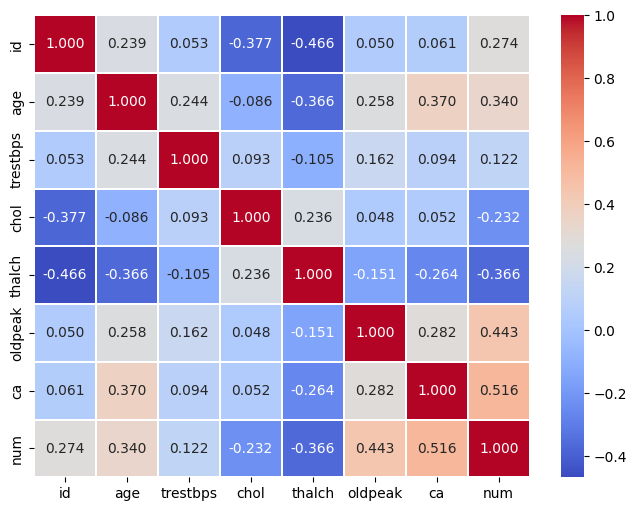

In [11]:
# Calculate the correlation matrix
correlation_matrix = numerical_data.corr()
display(correlation_matrix)

# Plotting the heatmap for correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.show()

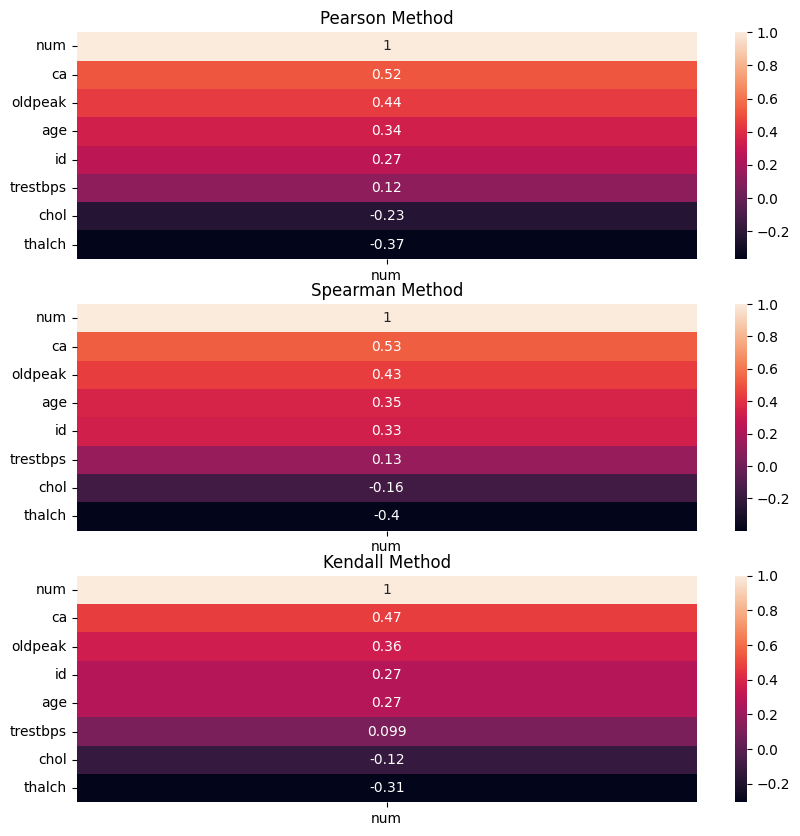

In [17]:
fig, ax = plt.subplots(3,1, figsize=(10, 10))
## Correlation coefficient using different methods
corr1 = numerical_data.corr('pearson')[['num']].sort_values(by='num', ascending=False)
corr2 = numerical_data.corr('spearman')[['num']].sort_values(by='num', ascending=False)
corr3 = numerical_data.corr('kendall')[['num']].sort_values(by='num', ascending=False)

#setting titles for each plot
ax[0].set_title('Pearson Method')
ax[1].set_title('Spearman Method')
ax[2].set_title('Kendall Method')

## Generating heatmaps of each methods
sns.heatmap(corr1, ax=ax[0], annot=True)
sns.heatmap(corr2, ax=ax[1], annot=True)
sns.heatmap(corr3, ax=ax[2], annot=True)

plt.show()

### Imbalance in Data

In [18]:
#check Imbalance in data

#group instances based on the classes in num variable
class_counts=dataset.groupby("num").size()

columns=['outcome','count','percentage']
outcome=[0,1]
count=list()
percentage=list()

#Calculate the percentage of each value of the OUTCOME variable from total
for val in range(2):
    count.append(class_counts[val])
    percent=(class_counts[val]/105000)*100
    percentage.append(percent)

# Convert the calulated values into a dataframe
imbalance_df=pd.DataFrame(list(zip(outcome,count,percentage)),columns=columns)
imbalance_df

KeyError: 'OUTCOME'

# Data Pre-Processing

In [12]:
# Encoding categorical data
df = pd.read_csv('drive/MyDrive/Labs/CSE422/Dataset/8.csv')
df_encode = df.copy()

thal_map = {'normal': 3.0, 'fixed defect': 6.0, 'reversable defect': 7.0}
df_encode['thal'] = df['thal'].map(thal_map)
df_encode['ca'] = pd.to_numeric(df['ca'], errors='coerce')  # Ensure numeric

df_encode.shape

(920, 16)

### Using KNN Imputation using k = 5 for ca, thal (has critical relationships, but badly damaged)

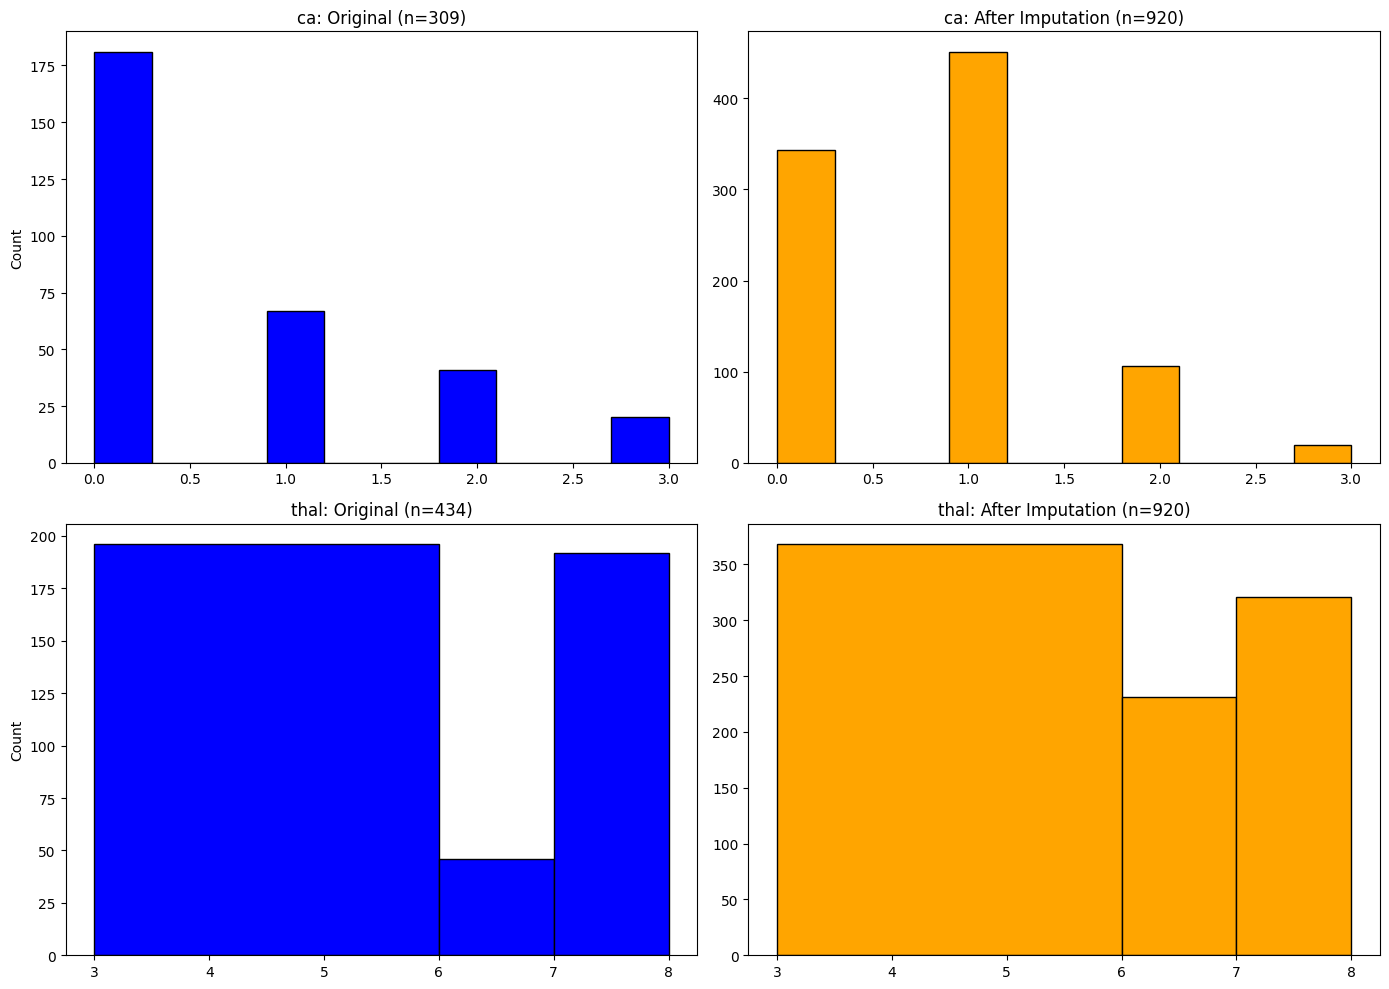


=== ca Distribution ===
Original:
 ca
0.0    181
1.0     67
2.0     41
3.0     20
Name: count, dtype: int64

Imputed:
 ca
0    343
1    451
2    106
3     20
Name: count, dtype: int64

=== thal Distribution ===
Original:
 thal
3.0    196
6.0     46
7.0    192
Name: count, dtype: int64

Imputed:
 thal
3    209
4     63
5     96
6    231
7    321
Name: count, dtype: int64

=== VALUE COUNTS COMPARISON ===
ca Original:
 ca
0.0    181
1.0     67
2.0     41
3.0     20
Name: count, dtype: int64

ca Imputed:
 ca
0    343
1    451
2    106
3     20
Name: count, dtype: int64

thal Original:
 thal
3.0    196
6.0     46
7.0    192
Name: count, dtype: int64

thal Imputed:
 thal
3    209
4     63
5     96
6    231
7    321
Name: count, dtype: int64

=== STATS COMPARISON (non-null only) ===
ca - Mean/Std orig: 0.68/0.94
ca - Mean/Std imputed: 0.68/0.94
thal - Mean/Std orig: 5.09/1.92
thal - Mean/Std imputed: 5.09/1.92

>>> Dataframe updated with imputed values!
Final shape: (920, 16)
>>> Saved as '8

In [13]:
# 1. Select numeric columns for imputation
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'thal']
X = df_encode[numeric_cols].copy()   # A copy of df with only numeric cols


# 2. Apply KNN Imputer
imputer = KNNImputer(n_neighbors=5, weights='distance')
X_imputed = imputer.fit_transform(X)
df_imputed = pd.DataFrame(X_imputed, columns=numeric_cols)


# 3. Round discrete variables (ca: 0/1/2/3, thal: 3/6/7)
df_imputed['ca'] = df_imputed['ca'].round().clip(0, 3).astype(int)
df_imputed['thal'] = np.round(df_imputed['thal']).clip(3, 7).astype(int)
df_imputed['thal'] = df_imputed['thal'].replace({3:3, 6:6, 7:7})  # Ensure exact values


# 4. Quality Verification histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ca - Original vs Imputed
axes[0, 0].hist(X['ca'].dropna(), bins=10, color='blue', edgecolor='black')
axes[0, 0].set_title('ca: Original (n={})'.format(X['ca'].notna().sum()))
axes[0, 0].set_ylabel('Count')

axes[0, 1].hist(df_imputed['ca'], bins=10, color='orange', edgecolor='black')
axes[0, 1].set_title('ca: After Imputation (n={})'.format(len(df_imputed)))

# thal - Original vs Imputed
axes[1, 0].hist(X['thal'].dropna(), bins=[3, 6, 7, 8], color='blue', edgecolor='black')
axes[1, 0].set_title('thal: Original (n={})'.format(X['thal'].notna().sum()))
axes[1, 0].set_ylabel('Count')

axes[1, 1].hist(df_imputed['thal'], bins=[3, 6, 7, 8], color='orange', edgecolor='black')
axes[1, 1].set_title('thal: After Imputation (n={})'.format(len(df_imputed)))

plt.tight_layout()
plt.show()

# Show value counts comparison
print("\n=== ca Distribution ===")
print("Original:\n", X['ca'].value_counts().sort_index())
print("\nImputed:\n", df_imputed['ca'].round().value_counts().sort_index())

print("\n=== thal Distribution ===")
print("Original:\n", X['thal'].value_counts().sort_index())
print("\nImputed:\n", df_imputed['thal'].round().value_counts().sort_index())


# 5. Value counts comparison
print("\n=== VALUE COUNTS COMPARISON ===")
print("ca Original:\n", X['ca'].value_counts().sort_index())
print("\nca Imputed:\n", df_imputed['ca'].value_counts().sort_index())
print("\nthal Original:\n", X['thal'].value_counts().sort_index())
print("\nthal Imputed:\n", df_imputed['thal'].value_counts().sort_index())


# 6. Stats comparison (non-null originals only)
print("\n=== STATS COMPARISON (non-null only) ===")
mask_ca = X['ca'].notna()
mask_thal = X['thal'].notna()
print(f"ca - Mean/Std orig: {X.loc[mask_ca, 'ca'].mean():.2f}/{X.loc[mask_ca, 'ca'].std():.2f}")
print(f"ca - Mean/Std imputed: {df_imputed.loc[mask_ca, 'ca'].mean():.2f}/{df_imputed.loc[mask_ca, 'ca'].std():.2f}")
print(f"thal - Mean/Std orig: {X.loc[mask_thal, 'thal'].mean():.2f}/{X.loc[mask_thal, 'thal'].std():.2f}")
print(f"thal - Mean/Std imputed: {df_imputed.loc[mask_thal, 'thal'].mean():.2f}/{df_imputed.loc[mask_thal, 'thal'].std():.2f}")


# 7. Update original dataframe (originals preserved)
df[numeric_cols] = df_imputed
print("\n>>> Dataframe updated with imputed values!")
print("Final shape:", df.shape)

# Save processed data
df.to_csv('drive/MyDrive/Labs/CSE422/Dataset/8_imputed.csv', index=False)
print(">>> Saved as '8_imputed.csv'")

# Model Training